# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Muhammad Fikri Rouzan Ash Shidik
- **Email:** fikrirzn@gmail.com
- **ID Dicoding:** fikri_rouzan

## Menentukan Pertanyaan Bisnis

- Pertanyaan 1: Bagaimana pengaruh musim dan kondisi cuaca terhadap jumlah total penyewaan sepeda harian selama tahun 2011-2012?
- Pertanyaan 2: Bagaimana pola penyewaan sepeda rata-rata berdasarkan jam dalam sehari selama tahun 2011-2012, dan bagaimana perbedaannya antara hari kerja dan hari libur?

## Import Semua Packages/Library yang Digunakan

In [215]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [216]:
# Dataset penyewaan sepeda harian
day_df = pd.read_csv("bike_sharing_day_dataset.csv")
print("====== Data Penyewaan Sepeda Harian ======")
display(day_df.head())

# Dataset penyewaan sepeda per jam
hour_df = pd.read_csv("bike_sharing_hour_dataset.csv")
print("\n====== Data Penyewaan Sepeda Per Jam ======")
display(hour_df.head())

====== Data Penyewaan Sepeda Harian ======


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600



====== Data Penyewaan Sepeda Per Jam ======


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
- Dataset penyewaan sepeda harian dan dataset penyewaan sepeda per jam berhasil ditampilkan dalam 5 baris pertama.
- Kedua dataset memiliki kolom yang sama terkait cuaca dan waktu, namun dataset penyewaan sepeda per jam memiliki tambahan kolom jam (hr) yang merepresentasikan waktu penyewaan secara lebih spesifik.

### Assessing Data

In [217]:
# Data penyewaan sepeda harian
print("====== Assessing Data Penyewaan Sepeda Harian ======")
print("\nInfo Tipe Data:")
day_df.info()
print("\nJumlah Missing Values:")
print(day_df.isna().sum())
print("\nJumlah Data Duplikat:", day_df.duplicated().sum())
print("\nStatistik Data:")
display(day_df.describe())

# Data penyewaan sepeda per jam
print("\n\n====== Assessing Data Penyewaan Sepeda Per Jam ======")
print("\nInfo Tipe Data:")
hour_df.info()
print("\nJumlah Missing Values:")
print(hour_df.isna().sum())
print("\nJumlah Data Duplikat:", hour_df.duplicated().sum())
print("\nStatistik Data:")
display(hour_df.describe())

====== Assessing Data Penyewaan Sepeda Harian ======

Info Tipe Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB

Jumlah Missing Values:

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000




====== Assessing Data Penyewaan Sepeda Per Jam ======

Info Tipe Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


**Insight:**
- Tidak ditemukan adanya missing values pada dataset penyewaan sepeda harian maupun pada dataset penyewaan sepeda per jam. Kedua dataset tersebut bersih (0 null).
- Tidak ditemukan adanya data yang terduplikasi pada kedua dataset tersebut.
- Terdapat kesalahan tipe data pada kolom dteday di kedua dataset. Kolom tersebut merepresentasikan tanggal, namun saat ini kolom tersebut bertipe object. Kolom ini perlu diubah menjadi tipe datetime pada tahap cleaning data berikutnya.
- Dataset penyewaan sepeda harian memiliki 731 entri data. Sedangkan dataset penyewaan sepeda per jam memiliki 17.379 entri data.

### Cleaning Data

In [218]:
# Mengubah tipe data dteday menjadi datetime
day_df["dteday"] = pd.to_datetime(day_df["dteday"])
hour_df["dteday"] = pd.to_datetime(hour_df["dteday"])

# Memetakan nilai numerik menjadi keterangan teks
season_mapping = {1: 'Semi', 2: 'Panas', 3: 'Gugur', 4: 'Dingin'}
weather_mapping = {1: 'Cerah', 2: 'Berawan', 3: 'Hujan/Bersalju', 4: 'Badai'}

day_df['season'] = day_df['season'].map(season_mapping)
day_df['weathersit'] = day_df['weathersit'].map(weather_mapping)

hour_df['season'] = hour_df['season'].map(season_mapping)
hour_df['weathersit'] = hour_df['weathersit'].map(weather_mapping)

# Binning pada dataset penyewaan sepeda per jam
def categorize_time(hour):
    if 3 <= hour <= 10:
        return 'Pagi'
    elif 11 <= hour <= 14:
        return 'Siang'
    elif 15 <= hour <= 19:
        return 'Sore'
    else:
        return 'Malam'

# Kolom baru
hour_df['time_category'] = hour_df['hr'].apply(categorize_time)
hour_df['time_category'] = pd.Categorical(hour_df['time_category'],
                                          categories=['Pagi', 'Siang', 'Sore', 'Malam'],
                                          ordered=True)

# Hasil cleaning
print("====== Info Dataset Penyewaan Sepeda Harian Setelah Cleaning ======")
day_df.info()
print("\n\n====== Info Dataset Penyewaan Sepeda Per Jam Setelah Cleaning ======")
hour_df.info()

print("\n=== Sampel Dataset Penyewaan Sepeda Per Jam Setelah Binning ===")
display(hour_df[['dteday', 'hr', 'time_category', 'cnt']].head())

====== Info Dataset Penyewaan Sepeda Harian Setelah Cleaning ======
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    object        
 3   yr          731 non-null    int64         
 4   mnth        731 non-null    int64         
 5   holiday     731 non-null    int64         
 6   weekday     731 non-null    int64         
 7   workingday  731 non-null    int64         
 8   weathersit  731 non-null    object        
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt   

,dteday,hr,time_category,cnt
0,2011-01-01,0,Malam,16
1,2011-01-01,1,Malam,40
2,2011-01-01,2,Malam,32
3,2011-01-01,3,Pagi,13
4,2011-01-01,4,Pagi,1


**Insight:**
- Kolom tanggal (dteday) pada kedua dataset telah berhasil diubah dari tipe object menjadi datetime64[ns].
- Kolom season dan weathersit telah dipetakan dari nilai numerik menjadi representasi string untuk mempermudah pemahaman saat visualisasi data.
- Kolom baru bernama time_category telah berhasil ditambahkan pada dataset penyewaan sepeda per jam. Kolom ini mengelompokkan jam penyewaan (hr) ke dalam 4 kelompok waktu (pagi, siang, sore, dan malam) untuk memfasilitasi pencarian pola penyewaan sepeda secara lebih mudah.

## Exploratory Data Analysis (EDA)

### Explore ...

In [219]:
# EDA penyewaan sepeda harian
print("====== Penyewaan Sepeda Harian Berdasarkan Musim ======")
display(day_df.groupby(by="season").agg({
    "cnt": ["max", "min", "mean", "std"]
}))

print("\n\n====== Penyewaan Sepeda Harian Berdasarkan Cuaca ======")
display(day_df.groupby(by="weathersit").agg({
    "cnt": ["max", "min", "mean", "std"]
}))

# EDA penyewaan sepeda per jam
print("\n\n====== Penyewaan Sepeda Per Jam Berdasarkan Kategori Waktu ======")
display(hour_df.groupby(by="time_category", observed=True).agg({
    "cnt": ["mean", "max", "min", "sum"]
}))

====== Penyewaan Sepeda Harian Berdasarkan Musim ======


cnt                                
         max   min         mean          std
season                                      
Dingin  8555    22  4728.162921  1699.615261
Gugur   8714  1115  5644.303191  1459.800381
Panas   8362   795  4992.331522  1695.977235
Semi    7836   431  2604.132597  1399.942119



====== Penyewaan Sepeda Harian Berdasarkan Cuaca ======


cnt                               
                 max  min         mean          std
weathersit                                         
Berawan         8362  605  4035.862348  1809.109918
Cerah           8714  431  4876.786177  1879.483989
Hujan/Bersalju  4639   22  1803.285714  1240.284449



====== Penyewaan Sepeda Per Jam Berdasarkan Kategori Waktu ======


cnt                  
                     mean  max min      sum
time_category                              
Pagi           136.292131  839   1   782862
Siang          239.033642  776   3   696305
Sore           352.350617  977   7  1284318
Malam          104.233603  584   1   529194

**Insight:**
- Musim gugur memiliki rata-rata penyewaan harian tertinggi, disusul oleh musim panas dan musim dingin. Musim semi mencatat rata-rata penyewaan terendah.
- Cuaca cerah memiliki rata-rata jumlah penyewaan terbanyak. Semakin buruk cuaca (hujan/bersalju), maka rata-rata penyewaan turun secara drastis. Tidak ada data penyewaan di saat badai (cuaca ekstrem) yang menunjukkan orang-orang sangat menghindari bersepeda saat cuaca sangat buruk.
- Rata-rata penyewaan tertinggi terjadi pada rentang waktu sore (jam 15:00 - 19:00) yang biasanya bertepatan dengan jam pulang kerja, disusul oleh waktu siang (jam 11.00 - 14.00) dan pagi (jam 03:00 - 10:00). Penyewaan paling sedikit terjadi pada waktu malam (jam 20:00 - 02:00) yang biasanya digunakan untuk beristirahat.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

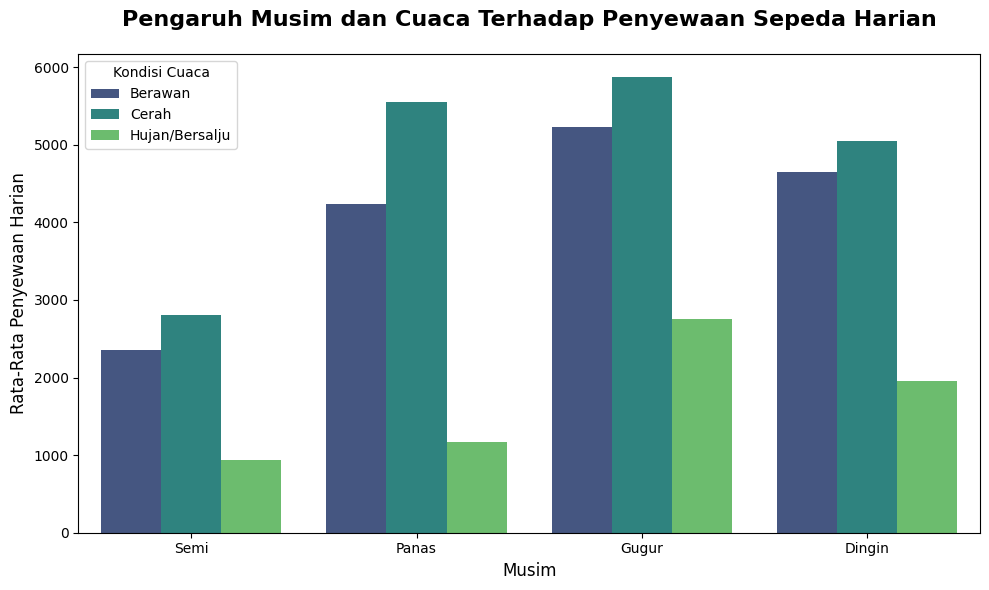

In [220]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x='season',
    y='cnt',
    hue='weathersit',
    data=day_df,
    palette='viridis',
    errorbar=None
)

plt.title('Pengaruh Musim dan Cuaca Terhadap Penyewaan Sepeda Harian', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Musim', fontsize=12)
plt.ylabel('Rata-Rata Penyewaan Harian', fontsize=12)
plt.legend(title='Kondisi Cuaca')
plt.tight_layout()
plt.show()

### Pertanyaan 2:

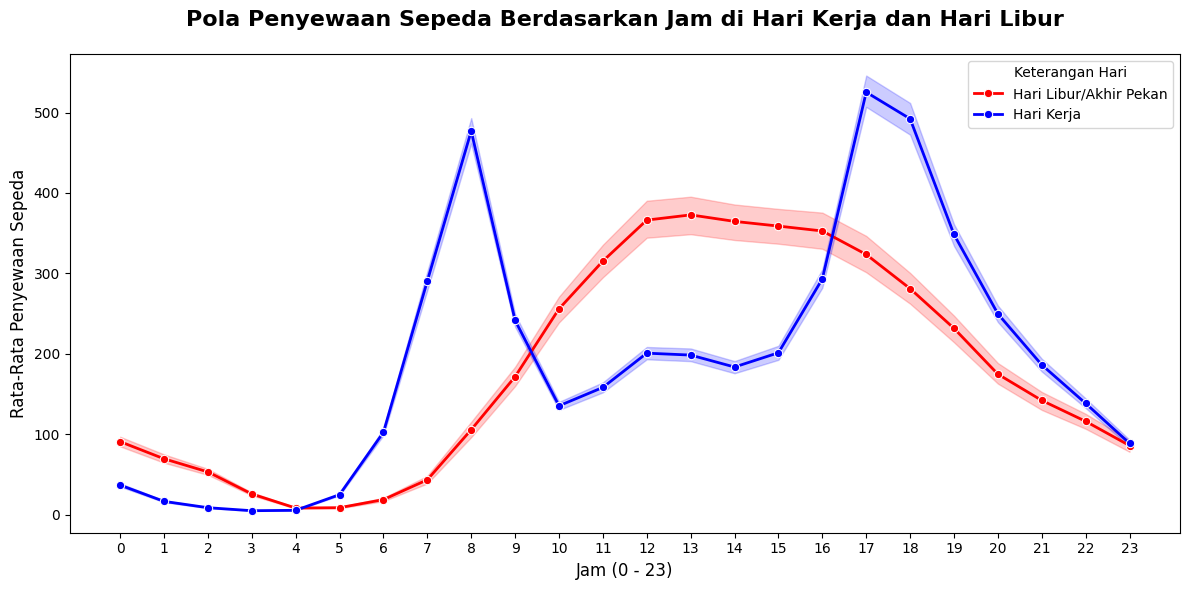

In [221]:
plt.figure(figsize=(12, 6))

plot_data = hour_df.copy()

plot_data['Keterangan Hari'] = plot_data['workingday'].map({
    0: 'Hari Libur/Akhir Pekan',
    1: 'Hari Kerja'
})

custom_color = {
    'Hari Libur/Akhir Pekan': 'red',
    'Hari Kerja': 'blue'
}

sns.lineplot(
    x='hr',
    y='cnt',
    hue='Keterangan Hari',
    data=plot_data,
    palette=custom_color,
    marker='o',
    linewidth=2
)

plt.title('Pola Penyewaan Sepeda Berdasarkan Jam di Hari Kerja dan Hari Libur', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Jam (0 - 23)', fontsize=12)
plt.ylabel('Rata-Rata Penyewaan Sepeda', fontsize=12)
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

**Insight:**
- Dari grafik terlihat jelas bahwa musim gugur menyumbang jumlah penyewaan sepeda tertinggi dibandingkan musim lainnya. Sebaliknya, musim semi adalah waktu yang paling sepi penyewa.
- Terlepas dari apa pun musimnya, cuaca cerah selalu menjadi kondisi favorit pelanggan untuk menyewa sepeda. Saat cuaca berubah menjadi berawan, terjadi penurunan jumlah penyewa. Penurunan ini semakin tajam dan drastis saat cuaca buruk seperti hujan/bersalju. Hal ini menunjukkan bahwa operasional bisnis ini sangat rentan terhadap perubahan cuaca.
- Terdapat dua puncak lonjakan aktivitas yang sangat menonjol, yaitu pada pukul 08:00 pagi dan rentang pukul 17:00 hingga 18:00 sore pada hari kerja. Pola ini mengonfirmasi bahwa pada hari kerja, mayoritas sepeda disewa oleh para pelanggan untuk mobilitas berangkat dan pulang bekerja atau bersekolah.
- Grafik penyewaan membentuk kurva cembung tunggal pada hari libur/akhir pekan. Penyewaan mulai stabil meningkat sejak pukul 08:00 pagi dan mencapai puncaknya pada siang hingga sore hari (pukul 12:00 - 16:00). Hal ini mengindikasikan bahwa pada hari libur, pelanggan menyewa sepeda untuk keperluan rekreasi, jalan-jalan santai, atau berolahraga, bukan untuk mobilitas yang terburu-buru.

## Analisis Lanjutan (Opsional)

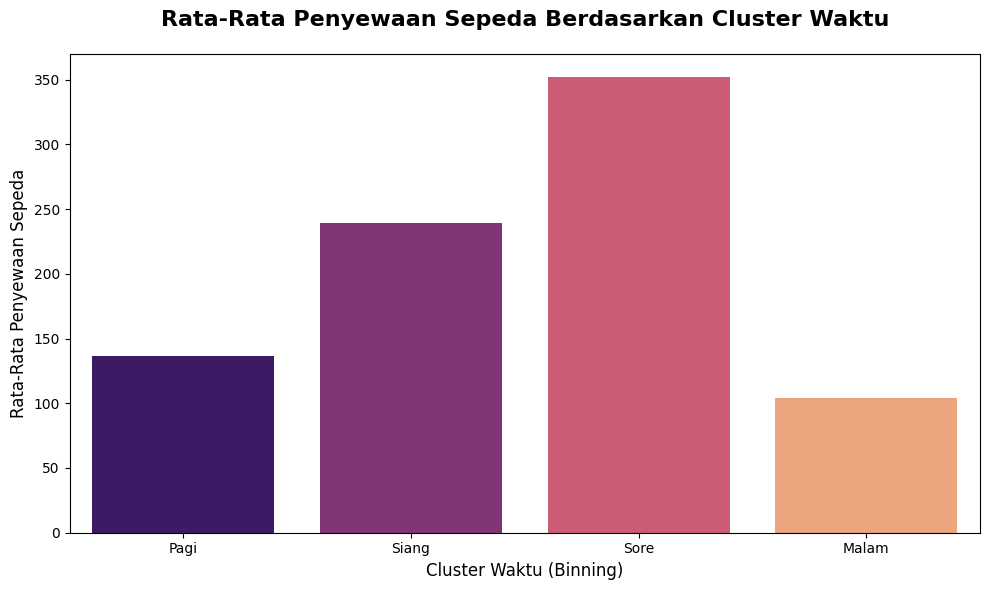

In [222]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x='time_category',
    y='cnt',
    data=hour_df,
    hue='time_category',
    palette='magma',
    errorbar=None,
    legend=False
)

plt.title('Rata-Rata Penyewaan Sepeda Berdasarkan Cluster Waktu', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Cluster Waktu (Binning)', fontsize=12)
plt.ylabel('Rata-Rata Penyewaan Sepeda', fontsize=12)
plt.tight_layout()
plt.show()

**Insight:**
- Melalui teknik pengelompokan (Binning), waktu 24 jam berhasil dibagi menjadi 4 cluster waktu berbeda yaitu pagi, siang, sore, dan malam.
- Visualisasi mengonfirmasi bahwa pada waktu sore (15:00 - 19:00) memiliki rata-rata penyewaan sepeda tertinggi, diikuti oleh waktu siang (11:00 - 14:00) dan pagi (jam 03:00 - 10:00). Hal ini selaras dengan jam komuter masyarakat.

## Conclusion

- Conclusion pertanyaan 1: Musim dan cuaca memiliki dampak yang sangat signifikan terhadap bisnis penyewaan sepeda. Musim gugur adalah waktu yang paling menguntungkan dengan rata-rata penyewaan tertinggi, sedangkan musim semi merupakan titik terendah. Dari segi cuaca, mayoritas pelanggan sangat memilih untuk menyewa sepeda pada cuaca cerah. Sebaliknya, terjadi penurunan penyewaan yang sangat drastis ketika cuaca berubah menjadi buruk (hujan/bersalju). Oleh karena itu, persiapan operasional dan perawatan sepeda paling baik difokuskan pada saat cuaca buruk ketika permintaan sedang rendah.
- Conclusion pertanyaan 2: Terdapat perbedaan pola perilaku pelanggan yang sangat kontras antara hari kerja dan hari libur. Pada hari kerja, pola penyewaan membentuk dua puncak lonjakan pada jam 08:00 pagi dan 17:00-18:00 sore, yang merupakan jam berangkat dan pulang bekerja atau bersekolah. Hal ini menunjukkan bahwa sepeda digunakan sebagai alat transportasi komuter harian. Sebaliknya, pada hari libur, polanya berubah menjadi satu puncak yang landai di siang hingga sore hari (pukul 12:00-16:00), mengindikasikan bahwa penggunaan sepeda lebih condong untuk rekreasi atau olahraga santai.